# EDACaP Seasonal Climate Forecast Module V2

This notebook is prepared for EDACaP Seasonal Climate forecast based of IRI NEXTGen seasonal climate forecasting workflow.This notebook uses PyCPT v2 utilities to 

1. download data from the IRI Data Library (through the CPT-DL python library) 
2. Run bias-correction using the IRI Climate Predictability Tool (through its companion python library, CPT-CORE) 
3. Plot skills scores and spatial loadings
4. Produce a multi-model ensemble forecast by taking the simple average of the bias-corrected members
5. Plots skill scores, deterministic forecasts, probabilistic forecasts, and exceedance probabilities for this NextGen MME forecast. 

#### Imports - This cell imports PyCPTv2 libraries 

In [ ]:
import pycpt
import packaging
min_version = '2.5.0'
assert packaging.version.parse(pycpt.__version__) >= packaging.version.parse(min_version), f'This notebook requires version {min_version} or higher of the pycpt library, but you have version {pycpt.__version__}. Please close the notebook, update your environment, and load the notebook again. See https://iri-pycpt.github.io/installation/'

import cptdl as dl 
from cptextras import get_colors_bars
import datetime as dt
import numpy as np
from pathlib import Path
import xarray as xr
import sys

: 

#### Define season and case directory
You can pass those value either from the the name list 

In [ ]:
print("PARAMETERS--------------")
ini_mon = sys.argv[1]
print(ini_mon)
fcst_season = sys.argv[2].split(",")
print(fcst_season)
fcst_season1, fcst_season2 = fcst_season
print(fcst_season1)
print(fcst_season2)
llow = sys.argv[3].split(",")
print(llow)
lhigh = sys.argv[4].split(",")
print(lhigh)
MOS = sys.argv[5]#'CCA' # must be one of 'CCA', 'PCR'
print(MOS)
# your selections for your predictors and predictands.
predictor_names = sys.argv[6].split(",") #[ "SEAS51.PRCP","GCFS2p1.PRCP","METEOFRANCE8.PRCP","SPEAR.PRCP", "CCSM4.PRCP"]
print(predictor_names)
predictand_name = sys.argv[7] #'UCSB.PRCP'
print(predictand_name)
first_year = sys.argv[8]
final_year = sys.argv[9]
predictor_extent = sys.argv[10].split(",")
print(predictor_extent)
predictand_extent = sys.argv[11].split(",")
print(predictand_extent)
tailoring = sys.argv[12]
print(tailoring)
cca_modes = sys.argv[13].split(",")
cca_modes = (int(cca_modes[0]), int(cca_modes[1]))
print(cca_modes)
x_eof_modes = sys.argv[14].split(",")
x_eof_modes = (int(x_eof_modes[0]), int(x_eof_modes[1]))
print(x_eof_modes)
y_eof_modes = sys.argv[15].split(",")
y_eof_modes = (int(y_eof_modes[0]), int(y_eof_modes[1]))
print(y_eof_modes)
scree = bool(sys.argv[16])
print(type(scree))



: 

In [28]:
fcst_year = dt.date.today().year
fmonth = dt.date.today().month
fcst_date = dt.datetime(fcst_year, fmonth, 1)

#Uncomment these lines if you dont want to these parameters to be passed using the json input file
#---------------------------------------------------------------------------------
ini_mon = fcst_date.strftime("%b")  
fcst_season1 = (dt.datetime(fcst_year,fcst_date.month+0,1).strftime("%b") + "-" + dt.datetime(fcst_year,fcst_date.month+2,1).strftime("%b"))
fcst_season2 = (dt.datetime(fcst_year,fcst_date.month+3,1).strftime("%b") + "-" + dt.datetime(fcst_year,fcst_date.month+5,1).strftime("%b"))
fcst_season = [fcst_season1, fcst_season2]
#---------------------------------------------------------------------------------
# llow = [0.5, 2.5]
# lhigh = [3.5, 5.5]
#case_dir = Path.home() / "Desktop/fcst_verfication" / fcst_season / (ini_mon + "_ini") / str(fcst_year)
print ("Forecast initilize on : " + ini_mon + ",  Target season : " + fcst_season1 + " and " + fcst_season2)

Forecast initilize on : Feb,  Target season : Feb-Apr and May-Jul


Forecast initilize on : Feb,  Target season : Feb-Apr PROCESS START
Input data will be saved in /Users/jemal/Desktop/fcst_verfication/2024/Feb-Apr/Feb_ini/53W-30E_to_0S-20N/data
Figures will be saved in /Users/jemal/Desktop/fcst_verfication/2024/Feb-Apr/Feb_ini/53W-30E_to_0S-20N/figures
Output will be saved in /Users/jemal/Desktop/fcst_verfication/2024/Feb-Apr/Feb_ini/53W-30E_to_0S-20N/output
URL: https://iridl.ldeo.columbia.edu/SOURCES/.UCSB/.CHIRPS/.v2p0/.daily-improved/.global/.0p25/.prcp/89.25/mul/T/(1%20Jan%201993)/(31%20Dec%202016)/RANGE/T/%28Feb-Apr%201993-2016%29/seasonalAverage/Y/%283%29/%2816%29/RANGEEDGES/X/%2849%29/%2832%29/RANGEEDGES/-999/setmissing_value/%5BX/Y%5D%5BT%5Dcptv10.tsv

DOWNLOADING: [*************************] (1223 KB) 0:00:32.623348
URL: https://iridl.ldeo.columbia.edu/SOURCES/.EU/.Copernicus/.CDS/.C3S/.ECMWF/.SEAS51/.hindcast/.prcp/S/%280000%201%20Feb%201993-2016%29/VALUES/L/0.5/3.5/RANGEEDGES/%5BL%5D//keepgrids/average/Y/0/20/RANGEEDGES/X/53/30/RANGEEDGES/

DOWNLOADING: [*************************] (186 KB) 0:00:43.489266
URL: https://iridl.ldeo.columbia.edu/SOURCES/.Models/.NMME/.COLA-RSMAS-CCSM4/.MONTHLY/.prec/S/%280000%201%20Feb%201993-2016%29/VALUES/L/2.5/5.5/RANGEEDGES/%5BL%5D//keepgrids/average/Y/0/20/RANGEEDGES/X/53/30/RANGEEDGES/%5BM%5D/average/92/mul/-999/setmissing_value/%5BX/Y%5D%5BL/S/add%5D/cptv10.tsv

DOWNLOADING: [*************************] (187 KB) 0:00:04.422048
URL: https://iridl.ldeo.columbia.edu/SOURCES/.EU/.Copernicus/.CDS/.C3S/.ECMWF/.SEAS51/.forecast/.prcp/S/%280000%201%20Feb%202024%29/VALUES/L/2.5/5.5/RANGEEDGES/%5BL%5D//keepgrids/average/Y/0/20/RANGEEDGES/X/53/30/RANGEEDGES/%5BM%5D/average/c%3A/1000/(mm%20m-1)/%3Ac/mul/c%3A/86400/(s%20day-1)/%3Ac/mul/c%3A/92//units/(days)/def/%3Ac/mul/-999/setmissing_value/%5BX/Y%5D%5BL/S/add%5D/cptv10.tsv

DOWNLOADING: [*************************] (8 KB) 0:00:00.588605
URL: https://iridl.ldeo.columbia.edu/SOURCES/.EU/.Copernicus/.CDS/.C3S/.DWD/.GCFS2p1/.forecast/.prcp/S/%280000%201

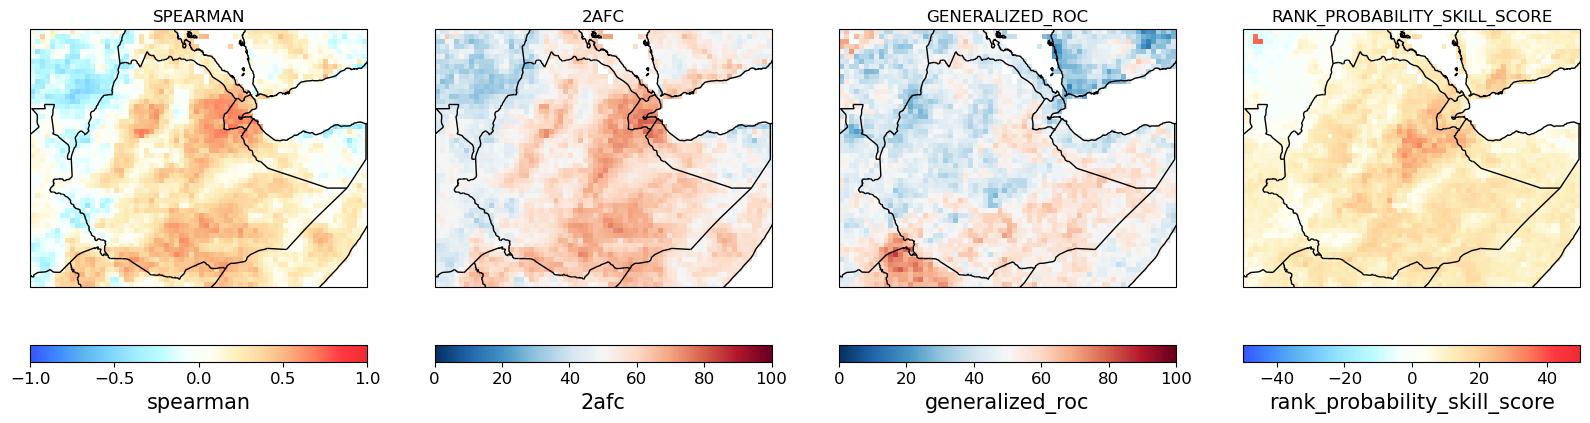

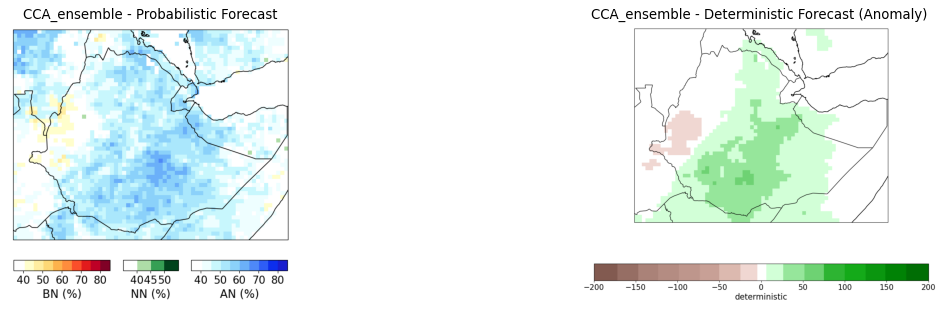

<Figure size 700x900 with 0 Axes>

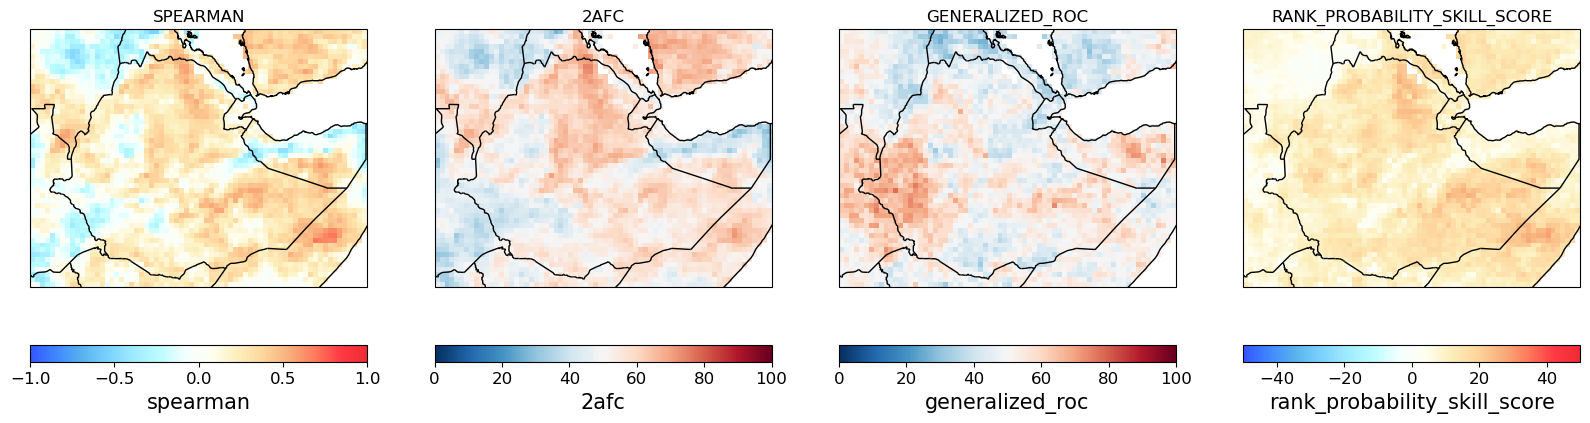

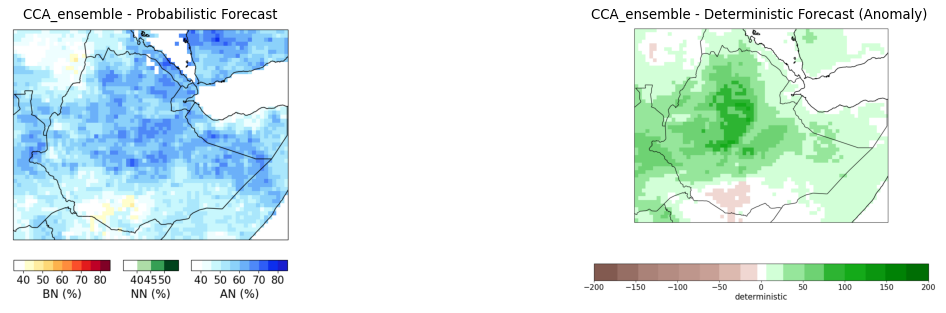

<Figure size 700x900 with 0 Axes>

In [30]:
for ii in range(len(fcst_season)):

    case_dir = Path.home() / "EDACaP_Seasonal_fcst" / str(fcst_year) / fcst_season[ii]
    print ("Forecast initilize on : " + ini_mon + ",  Target season : " + fcst_season[ii] + " PROCESS START")

 
    local_predictand_file = None


    download_args = { 
        # 'fdate':
        #   The initialization date of the model forecasts / hindcasts.
        #   This field is defined by a python datetime.datetime object,
        #   for example: dt.datetime(2022, 5, 1) # YYYY, MM, DD as integers
        #   The year field is only used for forecasts, otherwise ignored.
        #   The day field is only used in subseasonal forecasts, otherwise ignored.
        #   The month field is an integer representing a month - ie, May=5.
        'fdate':  fcst_date, #dt.datetime(2024, 1, 1), #dt.date.today(), #datetime(2023, 5, 1),

        # 'first_year':
        #   The first year of hindcasts you want. **NOT ALL MODELS HAVE ALL YEARS**.
        #   Double check that your model has hindcast data for all years in [first_year, final_year].
        #   This field is defined by a python integer representing a year, e.g. 1993.
        'first_year': first_year,#1993,  

        # 'final_year':
        #   The final year of hindcasts you want. **NOT ALL MODELS HAVE ALL YEARS**.
        #   Double check that your model has hindcast data for all years in [first_year, final_year].
        #   This field is defined by a python integer representing a year, e.g. 2016.
        'final_year': final_year, #2016,  

        # 'lead_low': 
        #   The number of months from the first of the initialization month to the center of 
        #   the first month included in the target period. Always an integer + 0.5. 
        #   This field is defined by a python floating point number 
        #   for example  a lead-1 forecast would use lead_low=1.5, if you want init=may, target=Jun-..
        'lead_low': float(llow[ii]), #3.5,

        # 'lead_high': 
        #   The number of months from the first of the initialization month to the center of 
        #   the last month included in the target period. Always an integer + 0.5. 
        #   This field is defined by a python floating point number 
        #   for example  a forecast initialized in may, whose target period ended in Aug, 
        #   would use lead_high=3.5
        'lead_high': float(lhigh[ii]), #5.5, 

        # 'target': 
        #   Mmm-Mmm indicating the months included in the target period of the forecast. 
        #   This field is defined by a python string, with two three-letter month name abbreviations 
        #   whose first letters are capitalized, and all other letters are lowercase
        #   and who are separated by a dash character. 
        #   For example, if you wanted a JJA target period, you would use 'Jun-Aug'.
        'target': fcst_season[ii], #'Feb-Apr',

        # 'predictor_extent':
        #   The geographic bounding box of the climate model data you want to download.
        #   This field is defined by a python dictionary with the keys "north", "south",
        #   "east", and "west", each of which maps to a python integer representing the 
        #   edge of a bounding box. i.e., "north" will be the northernmost boundary,
        #   "south" the southernmost boundary.
        #   Example: {"north": 90, "south": -90, "east": 0, "west": 180}
        'predictor_extent': {
            'east':  int(predictor_extent[0]),
            'west': int(predictor_extent[1]), 
            'north': int(predictor_extent[2]),
            'south': int(predictor_extent[3]), 
          }, 
       

        # 'predictand_extent':
        #   The geographic bounding box of the observation data you want to download.
        #   This field is defined by a python dictionary with the keys "north", "south",
        #   "east", and "west", each of which maps to a python integer representing the 
        #   edge of a bounding box. i.e., "north" will be the northernmost boundary,
        #   "south" the southernmost boundary.
        #   Example: {"north": 90, "south": -90, "east": 0, "west": 180}
        'predictand_extent': {
            'east':  int(predictand_extent[0]),
            'west': int(predictand_extent[1]), 
            'north': int(predictand_extent[2]),
            'south': int(predictand_extent[3]), 
          }, 

        # 'filetype':
        #   The filetype to be downloaded. for now, it saves a lot of headache just to set this equal
        #   to 'cptv10.tsv' which is a boutique plain-text CPT filetype based on .tsv + metadata.
        'filetype': 'cptv10.tsv'
    }

    cpt_args = { 
        'transform_predictand': None,  # transformation to apply to the predictand dataset - None, 'Empirical', 'Gamma'
        'tailoring': tailoring,#'Anomaly',  # tailoring None, 'Anomaly'
        'cca_modes': cca_modes,#(1,3), # minimum and maximum of allowed CCA modes 
        'x_eof_modes': x_eof_modes,#(1,8), # minimum and maximum of allowed X Principal Componenets 
        'y_eof_modes': y_eof_modes,#(1,6), # minimum and maximum of allowed Y Principal Components 
        'validation': 'crossvalidation', # the type of validation to use; only 'crossvalidation' is supported for now
        'drymask': False, #whether or not to use a drymask of -999
        'scree': scree, #True, # whether or not to save % explained variance for eof modes
        'crossvalidation_window': 5,  # number of samples to leave out in each cross-validation step 
        'synchronous_predictors': True, # whether or not we are using 'synchronous predictors'
    }
    
    force_download = True
    
    domain_dir = pycpt.setup(case_dir, download_args["predictor_extent"])
    NextGen_fcstDir = domain_dir / 'output'
    
    # Download Observations, Hindcasts, and Forecasts from IRI Data Library¶
    Y, hindcast_data, forecast_data = pycpt.download_data(predictand_name, local_predictand_file, predictor_names, download_args, domain_dir, force_download)
    
    interactive = False
    
    hcsts, fcsts, skill, pxs, pys = pycpt.evaluate_models(hindcast_data, MOS, Y, forecast_data, cpt_args, domain_dir, predictor_names, interactive)
    
    skill_metrics = [
    "pearson",
    "spearman",
    "two_alternative_forced_choice",
    "roc_area_below_normal",
    "roc_area_above_normal",
    ]
    
    # Multi-Model Ensemble
    ensemble = predictor_names
    
    det_fcst, pr_fcst, pev_fcst, nextgen_skill = pycpt.construct_mme(fcsts, hcsts, Y, ensemble, predictor_names, cpt_args, domain_dir)
    
    # Deterministic forecast skill 
    skill_metrics = ["spearman", "2afc", "generalized_roc", "rank_probability_skill_score"]
    pycpt.plot_mme_skill(predictor_names, nextgen_skill, MOS, domain_dir, skill_metrics)
    pycpt.plot_mme_forecasts(cpt_args, predictand_name, pr_fcst, MOS, domain_dir, det_fcst)
    
    # EDACaP output preparation
    data = xr.open_dataset(domain_dir / 'output' / ('MME_probabilistic_forecast_' + str(download_args["fdate"].year) +'.nc'))
    split_and_renamed_datasets = {}
    category_mapping = {'1': 'Below_Normal', '2': 'Normal', '3': 'Above_Normal'}
    for value in data['C'].values:
        selected_data = data.sel(C=value)
        new_name = category_mapping[str(value)]
        renamed_data = selected_data.rename({'probabilistic': new_name, 'T': 'Time', 'X': 'longitude', 'Y': 'latitude'})
        split_and_renamed_datasets[new_name] = renamed_data.drop_vars('C')
    merged_dataset = xr.merge(split_and_renamed_datasets.values())
    merged_dataset.to_netcdf(domain_dir / 'output' / ('NextGEN_probabilistic_' + download_args["target"] + str(download_args["fdate"].year) + '.nc' ))

    
print ("=============================================================================================")
print ("EDACaP FORECAST PROCESS FOR SEASSON : "  + fcst_season1 + " and " + fcst_season2, " COMPLETED")
print ("=============================================================================================")